In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from moco.loader import *
from moco.stain_augmentation import *
import matplotlib.pyplot as plt
import moco

In [3]:
dataset = TileDataset("/home/maelmontillet/primacode/images/")

In [4]:
len(dataset)

6

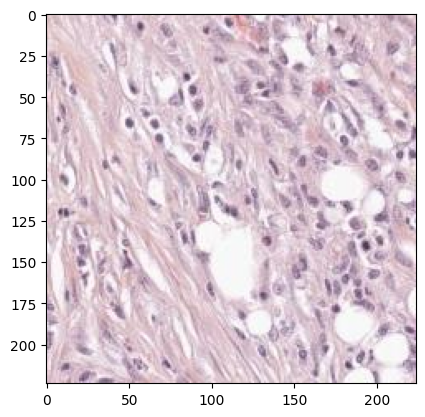

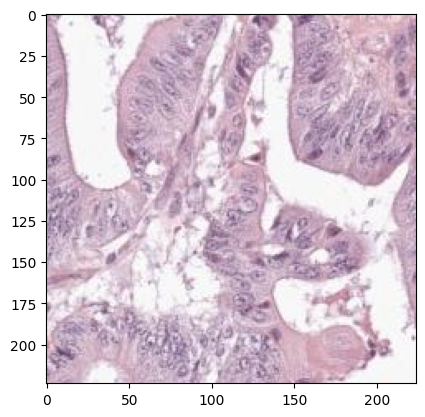

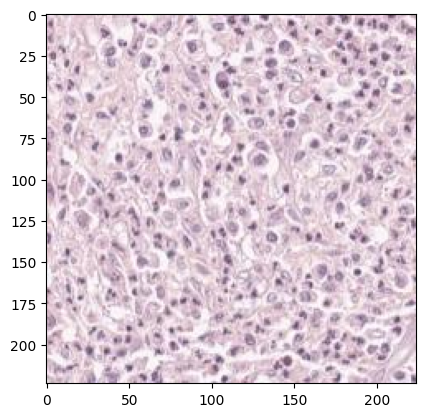

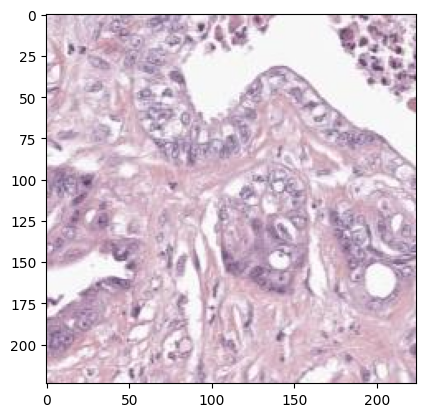

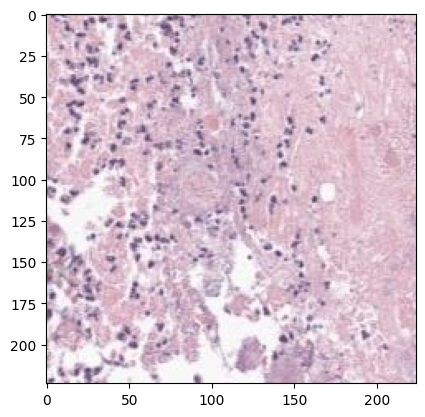

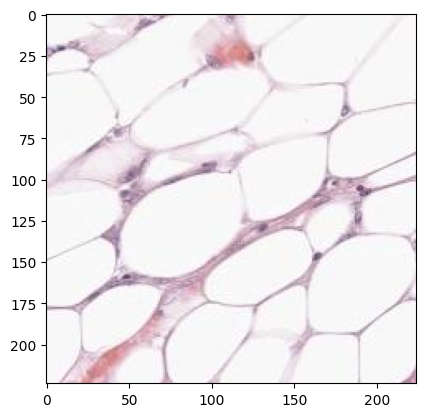

In [5]:
for img in dataset:
    plt.imshow(img)
    plt.show()

In [19]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

augmentation1 = [
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224, scale=(0.2, 1.)),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.2, 0.1)  # not strengthened
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([moco.loader.GaussianBlur([.1, 2.])], p=1.0),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
]

augmentation2 = [
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224, scale=(0.2, 1.)),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.2, 0.1)  # not strengthened
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([moco.loader.GaussianBlur([.1, 2.])], p=0.1),
    transforms.RandomApply([moco.loader.Solarize()], p=0.2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
]



# Num worker

train_loader = DataLoader(dataset, batch_size=2, shuffle=True, 
                        collate_fn = get_collate_function(transforms.Compose(augmentation1), 
                                                          transforms.Compose(augmentation2), 
                                                          moco.stain_augmentation.all_free_version()), 
                        pin_memory=True,  drop_last=True,
                        #num_workers=1,
                       )

0


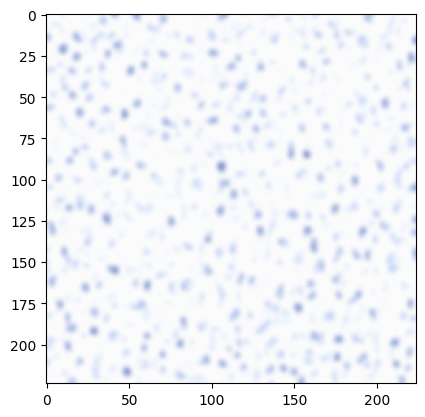

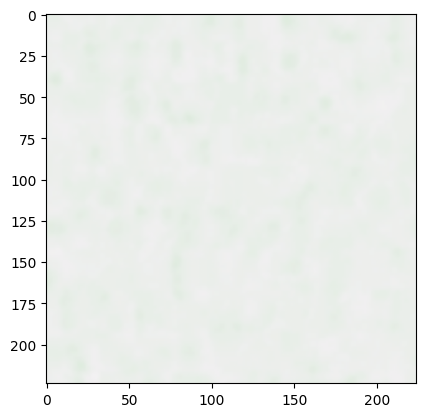

1


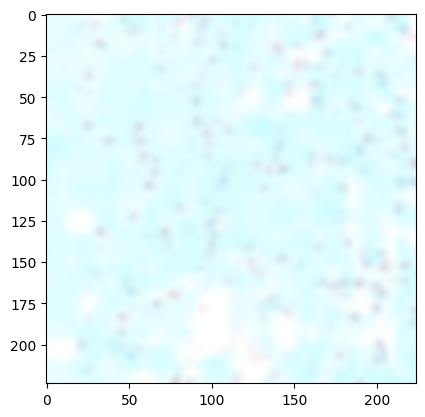

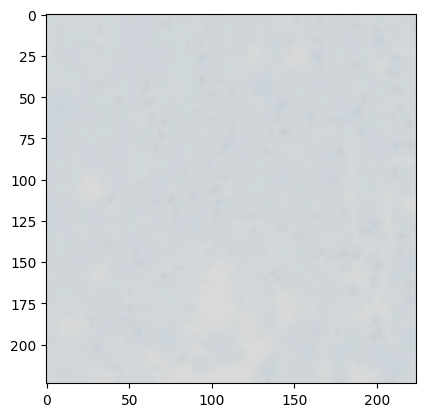

0


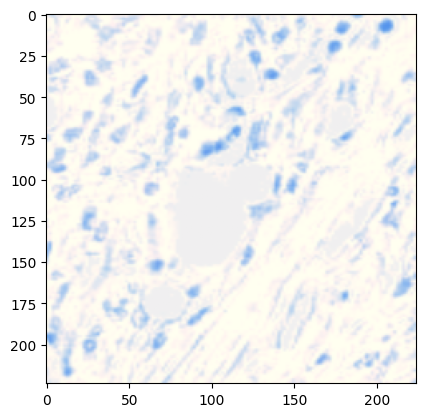

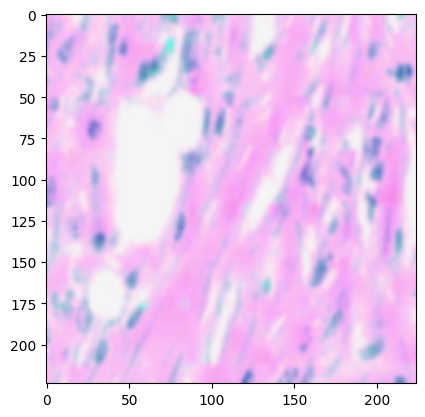

1


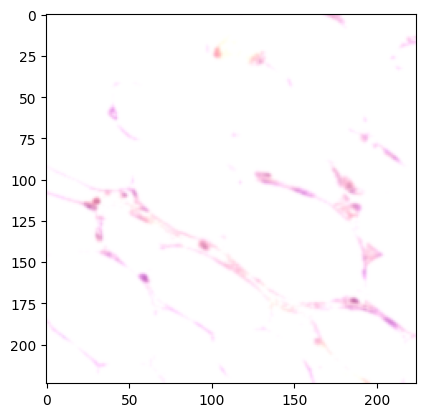

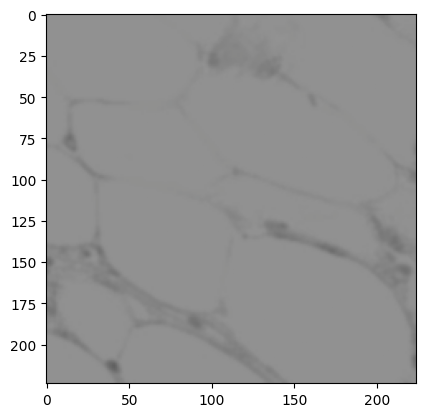

0


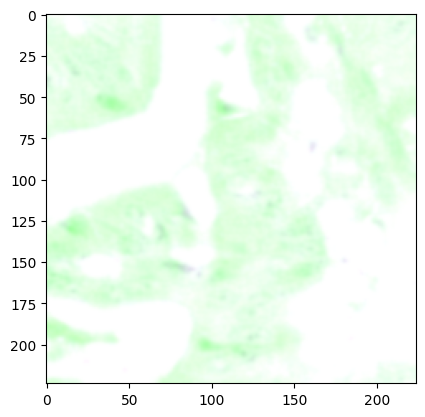

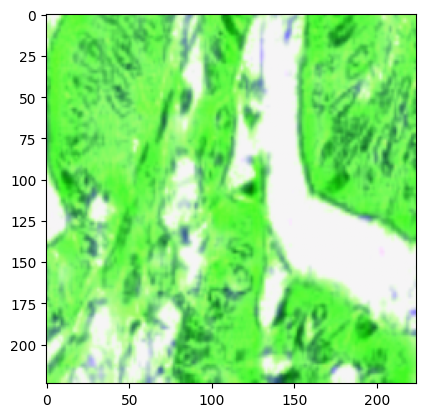

1


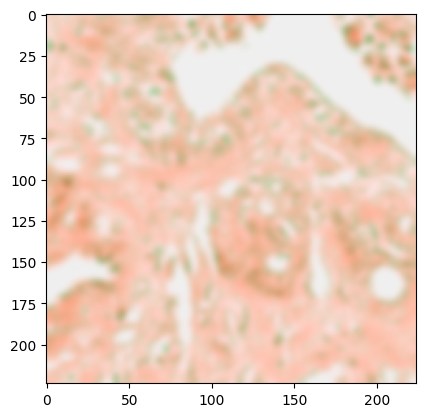

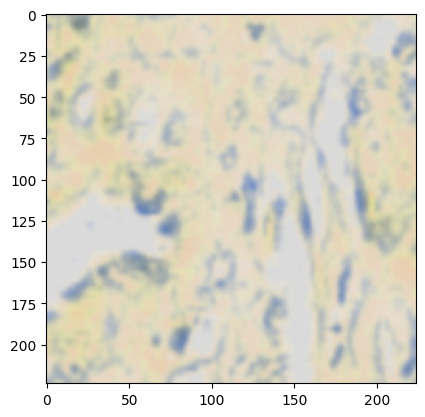

In [20]:
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)
for i, (images, _) in enumerate(train_loader):
    for i in range(len(images[0])):
        images[0] = images[0].cuda()
        images[1] = images[1].cuda()
        print(i)
        plt.imshow(inv_normalize(images[0][i].cpu()).permute(1, 2, 0))
        plt.show()
        plt.imshow(inv_normalize(images[1][i].cpu()).permute(1, 2, 0))
        plt.show()